In [1]:
# ML

#import data set

!pip install medmnist

In [2]:
import medmnist
print(medmnist.__version__)

3.0.2


In [3]:
from medmnist import DermaMNIST
train_dataset = DermaMNIST(split="train", download=True)

In [4]:
from medmnist import DermaMNIST
test_dataset = DermaMNIST(split="test", download=True)

In [5]:
# List all available dataset
from medmnist import DermaMNIST
from medmnist import INFO

# Load the dataset
data_flag = 'dermamnist'
download = True
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])
dataset = DataClass(split='train', download=download)


In [6]:
from medmnist import DermaMNIST
val_dataset = DermaMNIST(split="val", download=True)

In [7]:
from medmnist import DermaMNIST

# Load training, testing, and validation datasets
train_dataset = DermaMNIST(split="train", download=True)
test_dataset = DermaMNIST(split="test", download=True)
val_dataset = DermaMNIST(split="val", download=True)


In [8]:
import numpy as np

# Save the images and labels
images = dataset.imgs
labels = dataset.labels

np.save('dermamnist_images.npy', images)
np.save('dermamnist_labels.npy', labels)


In [9]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO, Evaluator

In [10]:
import medmnist
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")


MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/


# Work on a 2D dataset with size 28x28

In [11]:
data_flag = 'dermamnist'
download = True

# Class labels
classes = [
    'Actinic Keratosis',
    'Basal Cell Carcinoma',
    'Benign Keratosis',
    'Dermatofibroma',
    'Melanoma',
    'Melanocytic Nevus',
    'Vascular Lesion'
]

NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001
info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])
DataClass = getattr(medmnist, info['python_class'])



In [12]:
# Preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])
# Load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
#Encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=2*BATCH_SIZE, shuffle=False)


In [13]:
print(train_dataset)
print("===================")
print(test_dataset)

Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 7007
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
    Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
    Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
    License: CC BY-NC 4.0
Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 200

In [14]:
# visualization

train_dataset.montage(length=1)

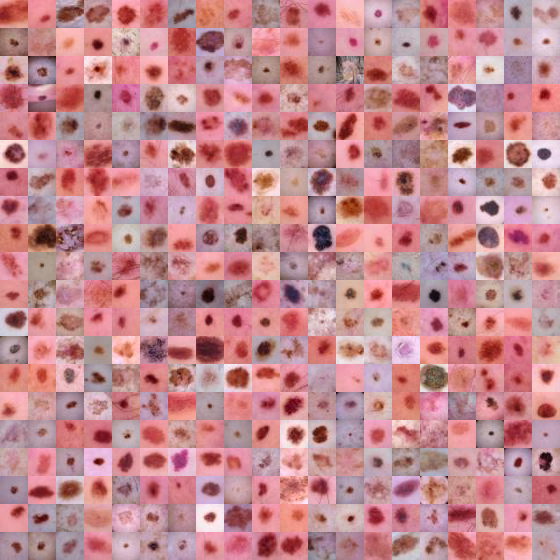

In [15]:
# montage

train_dataset.montage(length=20)

#EDA

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from medmnist import DermaMNIST, INFO
from torchvision import transforms
import warnings
warnings.filterwarnings('ignore')

In [17]:
# 1. Class Distribution Analysis
def plot_class_distribution(labels, split, filename):
    unique, counts = np.unique(labels.ravel(), return_counts=True)
    support = counts[np.argsort(unique)]
    plt.figure(figsize=(10, 6))
    bars = plt.bar(classes, support, color='skyblue', edgecolor='black')
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
                 ha='center', va='bottom', fontsize=10)
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.title(f'Class Distribution in DermaMNIST {split} Set', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    # plt.savefig(filename)
    # plt.close()
    return support




Class Distribution Summary:
Class                     Train      Val        Test      
Actinic Keratosis         228        33         66        
Basal Cell Carcinoma      359        52         103       
Benign Keratosis          769        110        220       
Dermatofibroma            80         12         23        
Melanoma                  779        111        223       
Melanocytic Nevus         4693       671        1341      
Vascular Lesion           99         14         29        

Gini Index (Imbalance Metric):
Training Set: 0.523
Validation Set: 0.524
Test Set: 0.524


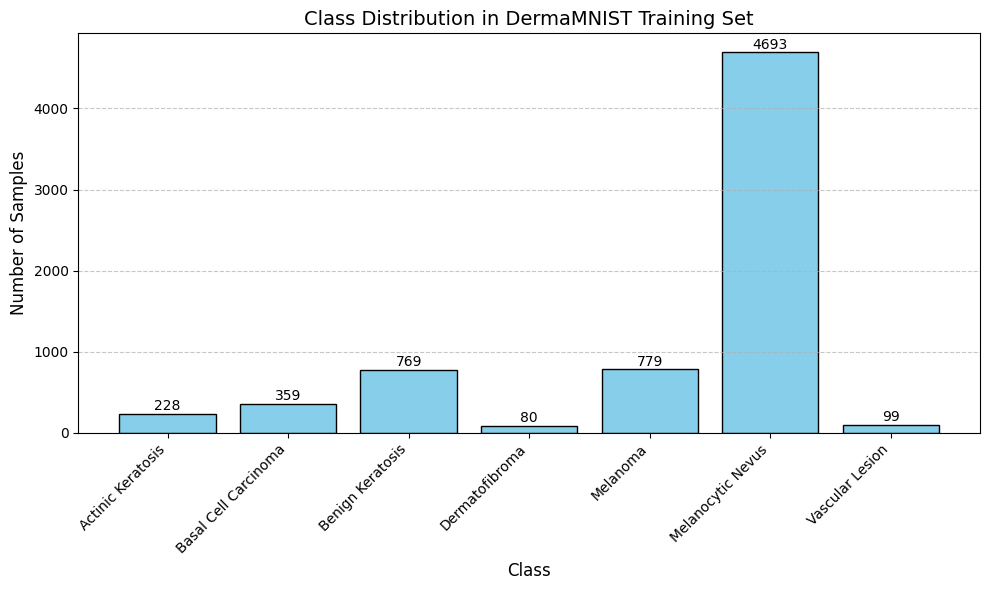

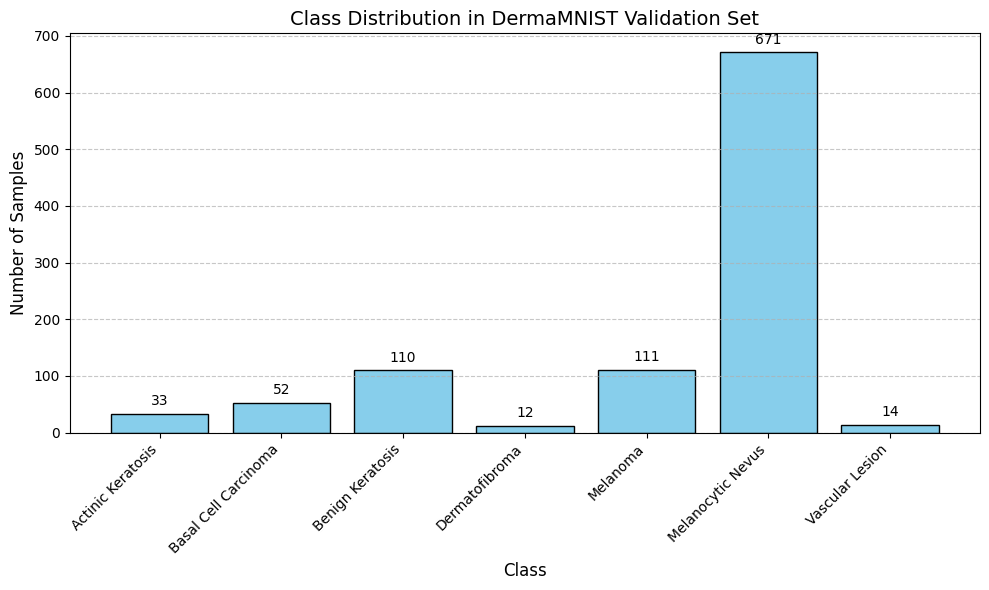

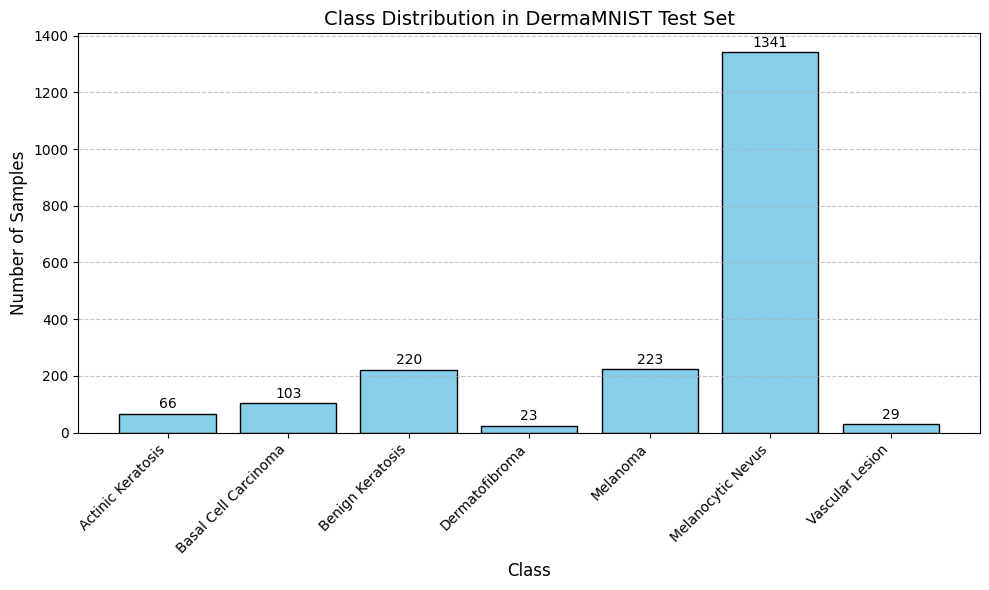

In [18]:
# Plot class distributions
train_support = plot_class_distribution(train_dataset.labels, 'Training', 'class_distribution_train.png')
val_support = plot_class_distribution(val_dataset.labels, 'Validation', 'class_distribution_val.png')
test_support = plot_class_distribution(test_dataset.labels, 'Test', 'class_distribution_test.png')

# Print class distribution summary
print("\nClass Distribution Summary:")
print(f"{'Class':<25} {'Train':<10} {'Val':<10} {'Test':<10}")
for i, cls in enumerate(classes):
    print(f"{cls:<25} {train_support[i]:<10} {val_support[i]:<10} {test_support[i]:<10}")

# Calculate Gini index for imbalance
def gini_index(support):
    proportions = support / np.sum(support)
    return 1 - np.sum(proportions**2)

print(f"\nGini Index (Imbalance Metric):")
print(f"Training Set: {gini_index(train_support):.3f}")
print(f"Validation Set: {gini_index(val_support):.3f}")
print(f"Test Set: {gini_index(test_support):.3f}")



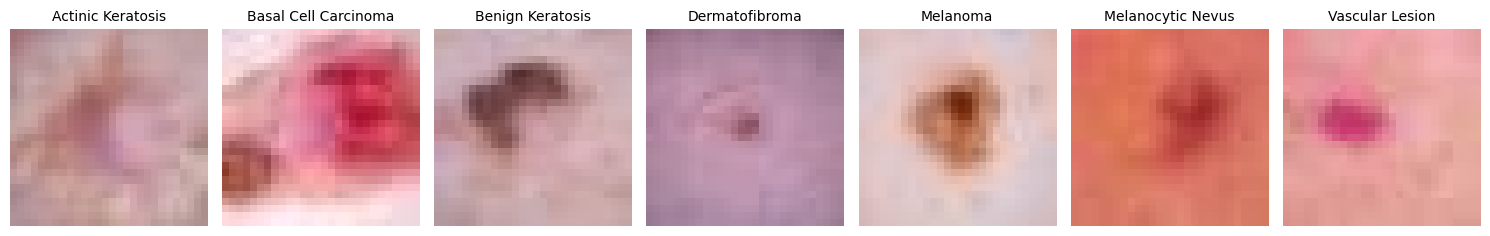

In [19]:
# 2. Visualize Sample Images
def plot_sample_images(dataset, filename):
    plt.figure(figsize=(15, 5))
    for i in range(n_classes):
        # Find first image of each class
        idx = np.where(dataset.labels.ravel() == i)[0][0]
        img = dataset.imgs[idx]  # Shape: (28, 28, 3)
        plt.subplot(1, n_classes, i+1)
        plt.imshow(img)
        plt.title(classes[i], fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    # plt.savefig(filename)
    # plt.close()

plot_sample_images(train_dataset, 'sample_images.png')



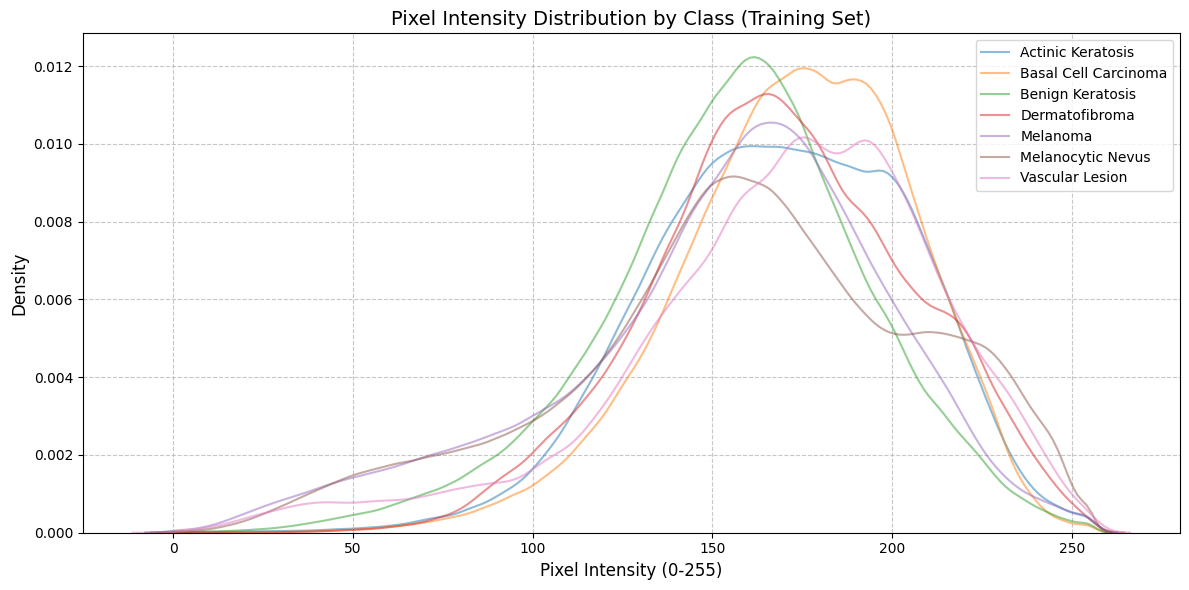

In [20]:
# 3. Pixel Intensity Distribution
def plot_pixel_intensity(dataset, filename):
    pixel_values = []
    for i in range(n_classes):
        class_indices = np.where(dataset.labels.ravel() == i)[0]
        class_images = dataset.imgs[class_indices]  # Shape: (n_samples, 28, 28, 3)
        pixel_values.append(class_images.flatten())

    plt.figure(figsize=(12, 6))
    for i, pixels in enumerate(pixel_values):
        sns.kdeplot(pixels, label=classes[i], alpha=0.5)
    plt.xlabel('Pixel Intensity (0-255)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title('Pixel Intensity Distribution by Class (Training Set)', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    # plt.savefig(filename)
    # plt.close()

plot_pixel_intensity(train_dataset, 'pixel_intensity_distribution.png')



In [21]:
# 4. Image Statistics (Mean and Std per Class)
def compute_image_stats(dataset):
    stats = []
    for i in range(n_classes):
        class_indices = np.where(dataset.labels.ravel() == i)[0]
        class_images = dataset.imgs[class_indices]  # Shape: (n_samples, 28, 28, 3)
        mean = np.mean(class_images, axis=(0, 1, 2))  # Mean across height, width, channels
        std = np.std(class_images, axis=(0, 1, 2))    # Std across height, width, channels
        stats.append((mean, std))
    return stats

train_stats = compute_image_stats(train_dataset)
print("\nImage Statistics (Mean and Std per Class, Training Set):")
print(f"{'Class':<25} {'Mean (R,G,B)':<20} {'Std (R,G,B)':<20}")
for i, (mean, std) in enumerate(train_stats):
    mean_str = f"({mean[0]:.2f}, {mean[1]:.2f}, {mean[2]:.2f})"
    std_str = f"({std[0]:.2f}, {std[1]:.2f}, {std[2]:.2f})"
    print(f"{classes[i]:<25} {mean_str:<20} {std_str:<20}")


Image Statistics (Mean and Std per Class, Training Set):
Class                     Mean (R,G,B)         Std (R,G,B)         
Actinic Keratosis         (200.28, 149.73, 155.88) (23.52, 28.06, 31.00)
Basal Cell Carcinoma      (198.05, 156.59, 163.60) (23.25, 28.04, 30.34)
Benign Keratosis          (180.38, 140.02, 147.24) (30.61, 31.72, 35.30)
Dermatofibroma            (199.36, 148.73, 157.65) (25.72, 28.71, 31.61)
Melanoma                  (178.32, 136.47, 142.83) (37.71, 42.16, 46.54)
Melanocytic Nevus         (198.93, 134.40, 139.72) (34.88, 40.64, 44.57)
Vascular Lesion           (197.84, 146.23, 161.58) (35.99, 41.89, 37.95)


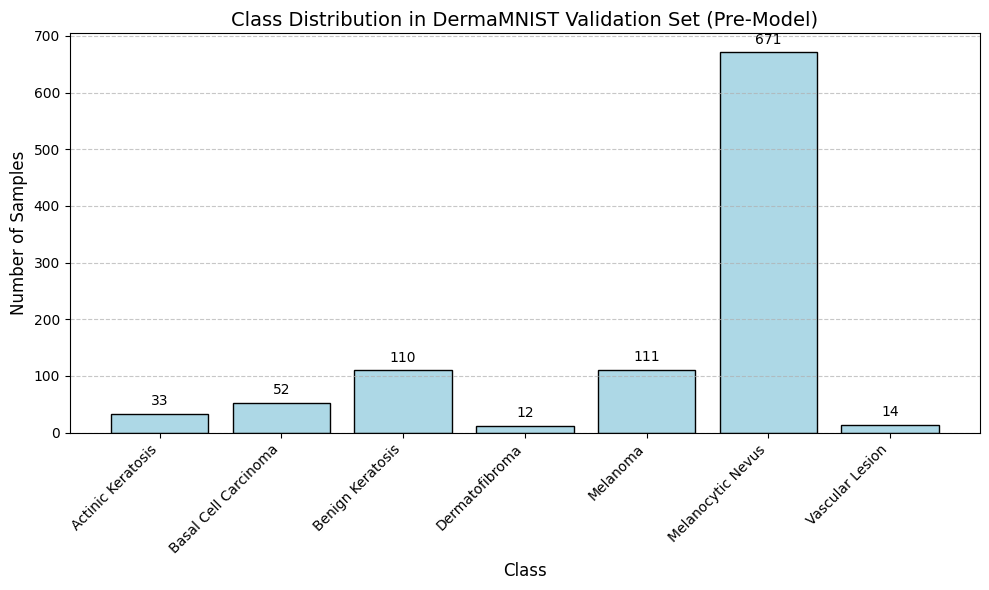

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import DermaMNIST
from torchvision import transforms

# Configuration for DermaMNIST dataset
data_flag = 'dermamnist'
download = True

# Class labels for DermaMNIST
classes = [
    'Actinic Keratosis',
    'Basal Cell Carcinoma',
    'Benign Keratosis',
    'Dermatofibroma',
    'Melanoma',
    'Melanocytic Nevus',
    'Vascular Lesion'
]

# Preprocessing (same as your original code)
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# Load the validation dataset
val_dataset = DermaMNIST(split='val', transform=data_transform, download=download)

# Extract labels and count samples per class
labels = val_dataset.labels.ravel()  # Flatten to 1D array
unique, counts = np.unique(labels, return_counts=True)
support = counts[np.argsort(unique)]  # Ensure counts align with class order 0-6

# Create bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, support, color='lightblue', edgecolor='black')

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
             ha='center', va='bottom', fontsize=10)

# Customize plot
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution in DermaMNIST Validation Set (Pre-Model)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
# plt.savefig('dermamnist_class_distribution_pre_model.png')
# plt.close()

# **Feature Extraction**

In [23]:
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern, hog
from skimage import exposure
import cv2

def extract_color_histogram(image, bins=(8, 8, 8)):
    # Convert the image to HSV color-space
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    # Compute the color histogram
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 256, 0, 256, 0, 256])
    # Normalize the histogram
    hist = cv2.normalize(hist, hist).flatten()
    return hist

In [24]:
def extract_hog_features(image):
    # Convert the image to grayscale
    gray = rgb2gray(image)
    # Compute HOG features
    hog_features, hog_image = hog(gray, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    return hog_features



In [25]:
def extract_lbp_features(image, P=8, R=1):
    # Convert the image to grayscale
    gray = rgb2gray(image)
    # Compute LBP features
    lbp = local_binary_pattern(gray, P, R, method='uniform')
    # Compute the histogram of LBP
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, P + 3), range=(0, P + 2))
    # Normalize the histogram
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

In [26]:
def extract_features(image):
    color_hist = extract_color_histogram(image)
    hog_features = extract_hog_features(image)
    lbp_features = extract_lbp_features(image)
    return np.hstack([color_hist, hog_features, lbp_features])

In [27]:
def extract_features_from_dataset(dataset):
    features = []
    labels = []
    for img, label in dataset:
        img = img.permute(1, 2, 0).numpy()  # Convert to HWC format
        feature = extract_features(img)
        features.append(feature)
        labels.append(label)
    return np.array(features), np.array(labels)

# Extract features for train, validation, and test datasets
X_train, y_train = extract_features_from_dataset(train_dataset)
X_val, y_val = extract_features_from_dataset(val_dataset)
X_test, y_test = extract_features_from_dataset(test_dataset)



# **Logistic Regression**

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve

# Initialize the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train, y_train)

# Validate the model
y_val_pred = log_reg.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_class_report = classification_report(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, log_reg.predict_proba(X_val), multi_class='ovr')

print(f"Validation Accuracy: {val_accuracy}")
print("Validation Confusion Matrix:")
print(val_conf_matrix)
print("Validation Classification Report:")
print(val_class_report)
print(f"Validation ROC-AUC: {val_roc_auc}")


Validation Accuracy: 0.6829511465603191
Validation Confusion Matrix:
[[  1   3  10   0   1  18   0]
 [  2   5   6   0   0  39   0]
 [  4   1  16   0   2  87   0]
 [  0   0   2   0   0  10   0]
 [  0   2   9   0   0 100   0]
 [  2   0   5   0   1 663   0]
 [  1   0   1   0   0  12   0]]
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.03      0.05        33
           1       0.45      0.10      0.16        52
           2       0.33      0.15      0.20       110
           3       0.00      0.00      0.00        12
           4       0.00      0.00      0.00       111
           5       0.71      0.99      0.83       671
           6       0.00      0.00      0.00        14

    accuracy                           0.68      1003
   macro avg       0.23      0.18      0.18      1003
weighted avg       0.54      0.68      0.59      1003

Validation ROC-AUC: 0.7567564828147784


In [29]:
# Test the model
y_test_pred = log_reg.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_class_report = classification_report(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, log_reg.predict_proba(X_test), multi_class='ovr')

print("\nTesting Results:")
print(f"Test Accuracy: {test_accuracy}")
print("Test Confusion Matrix:")
print(test_conf_matrix)
print("Test Classification Report:")
print(test_class_report)
print(f"Test ROC-AUC: {test_roc_auc}")


Testing Results:
Test Accuracy: 0.6822942643391521
Test Confusion Matrix:
[[   9    6   10    0    3   38    0]
 [   2    3   21    0    1   76    0]
 [   2    2   38    0    4  174    0]
 [   0    0    3    0    0   20    0]
 [   2    5    8    0    3  205    0]
 [   1    4   18    0    3 1315    0]
 [   0    0    0    0    0   29    0]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.14      0.22        66
           1       0.15      0.03      0.05       103
           2       0.39      0.17      0.24       220
           3       0.00      0.00      0.00        23
           4       0.21      0.01      0.03       223
           5       0.71      0.98      0.82      1341
           6       0.00      0.00      0.00        29

    accuracy                           0.68      2005
   macro avg       0.29      0.19      0.19      2005
weighted avg       0.57      0.68      0.59      2005

Test ROC-AUC: 0.7515183112809625


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import DermaMNIST, INFO
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [31]:
# Extract data for Logistic Regression
def extract_data(loader):
    X, y = [], []
    for images, labels in loader:
        images = images.numpy().reshape(images.shape[0], -1)  # Flatten: (batch_size, 28*28*3)
        labels = labels.numpy().ravel()  # Shape: (batch_size,)
        X.append(images)
        y.append(labels)
    return np.concatenate(X), np.concatenate(y)

X_train, y_train = extract_data(train_loader)
X_val, y_val = extract_data(val_loader)
X_test, y_test = extract_data(test_loader)

# Normalize to [0, 1] for scikit-learn
X_train = (X_train + 1) / 2
X_val = (X_val + 1) / 2
X_test = (X_test + 1) / 2

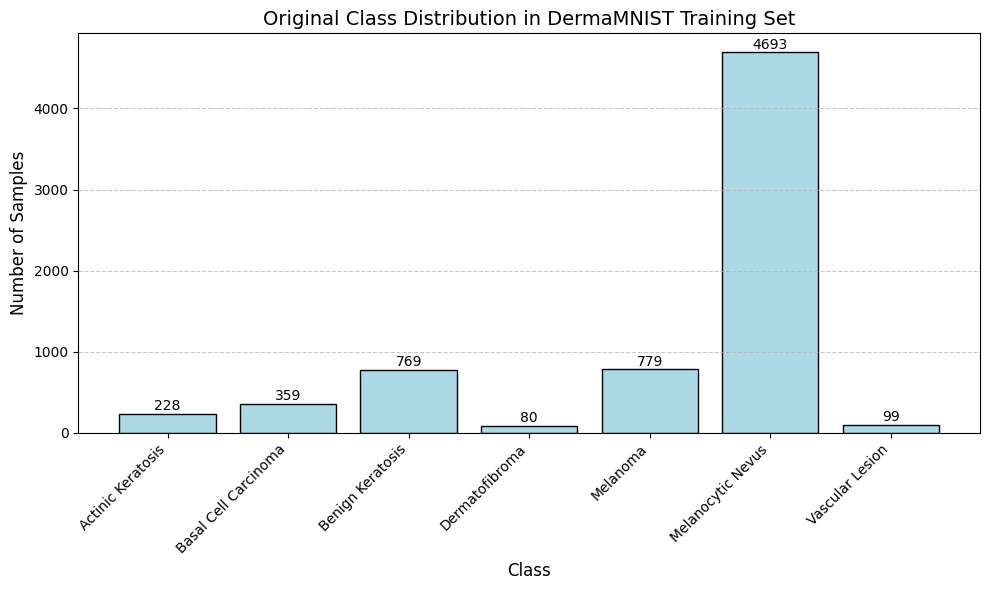

In [32]:
# Plot original training class distribution
unique, counts = np.unique(y_train, return_counts=True)
support_orig = counts[np.argsort(unique)]
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, support_orig, color='lightblue', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
             ha='center', va='bottom', fontsize=10)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Original Class Distribution in DermaMNIST Training Set', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('original_class_distribution.png')
# plt.close()

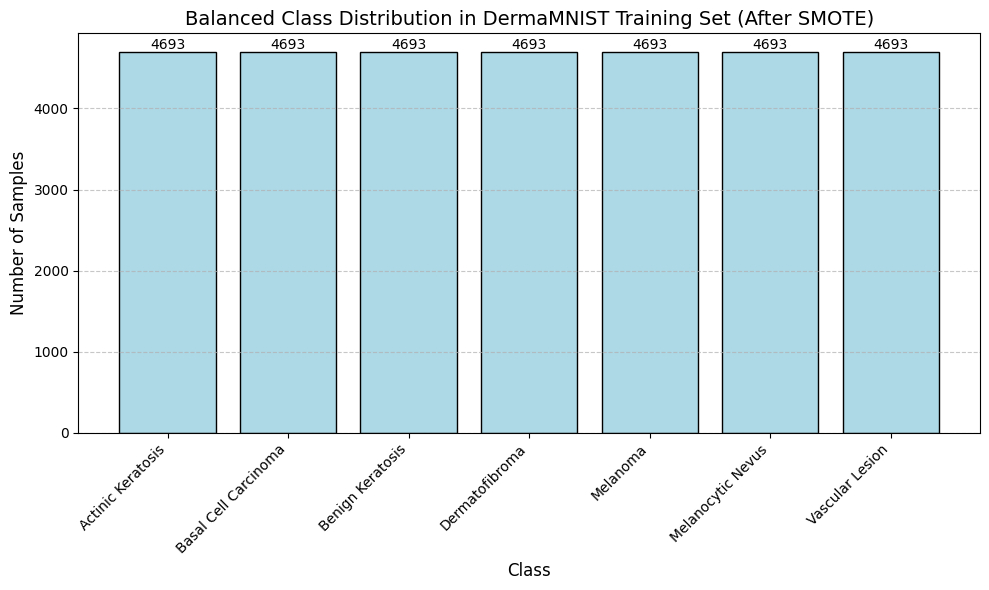

In [33]:
# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Plot balanced training class distribution
unique, counts = np.unique(y_train_balanced, return_counts=True)
support_balanced = counts[np.argsort(unique)]
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, support_balanced, color='lightblue', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
             ha='center', va='bottom', fontsize=10)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Balanced Class Distribution in DermaMNIST Training Set (After SMOTE)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('balanced_class_distribution.png')
# plt.close()

In [34]:
# Train Logistic Regression with class weights
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, class_weight='balanced')
model.fit(X_train_balanced, y_train_balanced)


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

In [35]:
# Evaluate on validation set
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=classes))


Validation Accuracy: 0.5174
Validation Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis       0.12      0.24      0.16        33
Basal Cell Carcinoma       0.26      0.42      0.32        52
    Benign Keratosis       0.26      0.34      0.29       110
      Dermatofibroma       0.07      0.25      0.11        12
            Melanoma       0.26      0.42      0.32       111
   Melanocytic Nevus       0.89      0.59      0.71       671
     Vascular Lesion       0.21      0.57      0.30        14

            accuracy                           0.52      1003
           macro avg       0.29      0.40      0.32      1003
        weighted avg       0.68      0.52      0.57      1003



In [36]:
# Evaluate on test set
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=classes))


Test Accuracy: 0.5401
Test Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis       0.14      0.32      0.20        66
Basal Cell Carcinoma       0.27      0.42      0.32       103
    Benign Keratosis       0.34      0.43      0.38       220
      Dermatofibroma       0.05      0.22      0.08        23
            Melanoma       0.24      0.38      0.29       223
   Melanocytic Nevus       0.90      0.61      0.73      1341
     Vascular Lesion       0.30      0.72      0.42        29

            accuracy                           0.54      2005
           macro avg       0.32      0.44      0.35      2005
        weighted avg       0.69      0.54      0.59      2005



# **SVM**

In [37]:
from sklearn.svm import SVC

# Initialize the SVM model
svm_model = SVC(probability=True)

# Train the model
svm_model.fit(X_train, y_train)

# Validate the model
y_val_pred = svm_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_class_report = classification_report(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, svm_model.predict_proba(X_val), multi_class='ovr')

print(f"Validation Accuracy: {val_accuracy}")
print("Validation Confusion Matrix:")
print(val_conf_matrix)
print("Validation Classification Report:")
print(val_class_report)
print(f"Validation ROC-AUC: {val_roc_auc}")


Validation Accuracy: 0.7218344965104686
Validation Confusion Matrix:
[[  2   4   6   0   0  21   0]
 [  2  23   6   0   0  21   0]
 [  0   8  32   0   0  70   0]
 [  2   6   0   0   0   4   0]
 [  0   0   6   0   6  99   0]
 [  0   0  10   0   0 661   0]
 [  1   2   1   0   0  10   0]]
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.06      0.10        33
           1       0.53      0.44      0.48        52
           2       0.52      0.29      0.37       110
           3       0.00      0.00      0.00        12
           4       1.00      0.05      0.10       111
           5       0.75      0.99      0.85       671
           6       0.00      0.00      0.00        14

    accuracy                           0.72      1003
   macro avg       0.44      0.26      0.27      1003
weighted avg       0.70      0.72      0.65      1003

Validation ROC-AUC: 0.9110270703471428


In [38]:
# Test the model
y_test_pred = svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_class_report = classification_report(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, svm_model.predict_proba(X_test), multi_class='ovr')

print(f"Test Accuracy: {test_accuracy}")
print("Test Confusion Matrix:")
print(test_conf_matrix)
print("Test Classification Report:")
print(test_class_report)
print(f"Test ROC-AUC: {test_roc_auc}")


Test Accuracy: 0.7107231920199502
Test Confusion Matrix:
[[   2   15   12    0    2   35    0]
 [   2   33    9    0    0   59    0]
 [   1    6   68    0    2  143    0]
 [   0    7    2    0    0   14    0]
 [   1    1   26    0    8  187    0]
 [   0    9   16    0    2 1314    0]
 [   1    4    2    0    0   22    0]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.03      0.05        66
           1       0.44      0.32      0.37       103
           2       0.50      0.31      0.38       220
           3       0.00      0.00      0.00        23
           4       0.57      0.04      0.07       223
           5       0.74      0.98      0.84      1341
           6       0.00      0.00      0.00        29

    accuracy                           0.71      2005
   macro avg       0.36      0.24      0.25      2005
weighted avg       0.65      0.71      0.63      2005

Test ROC-AUC: 0.897966457409873


In [39]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import DermaMNIST, INFO
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [40]:
# Normalize to [0, 1] for scikit-learn
X_train = (X_train + 1) / 2
X_val = (X_val + 1) / 2
X_test = (X_test + 1) / 2

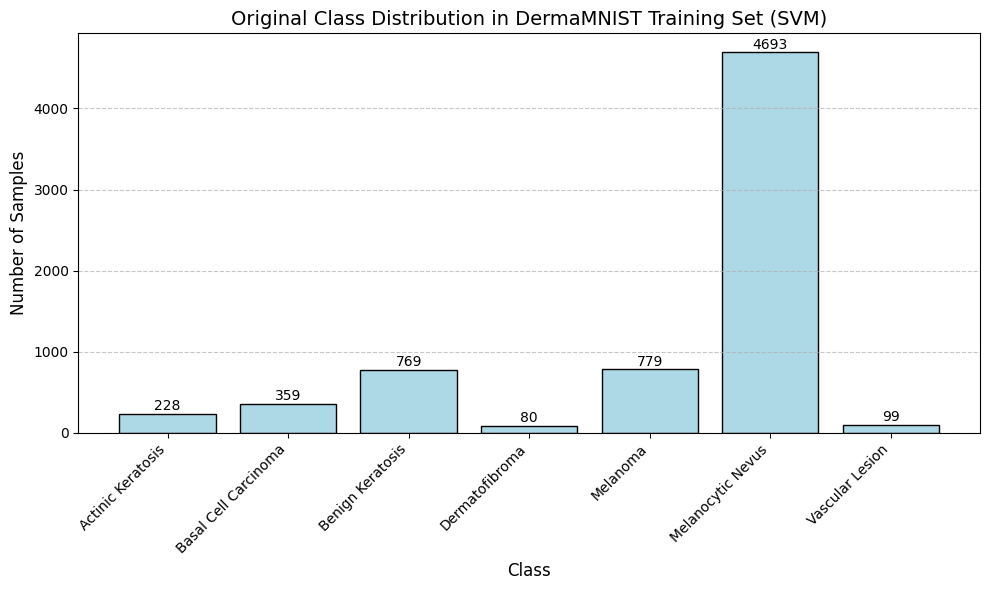

In [41]:
# Plot original training class distribution
unique, counts = np.unique(y_train, return_counts=True)
support_orig = counts[np.argsort(unique)]
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, support_orig, color='lightblue', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
             ha='center', va='bottom', fontsize=10)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Original Class Distribution in DermaMNIST Training Set (SVM)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('svm_original_class_distribution.png')
# plt.close()

In [42]:
# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

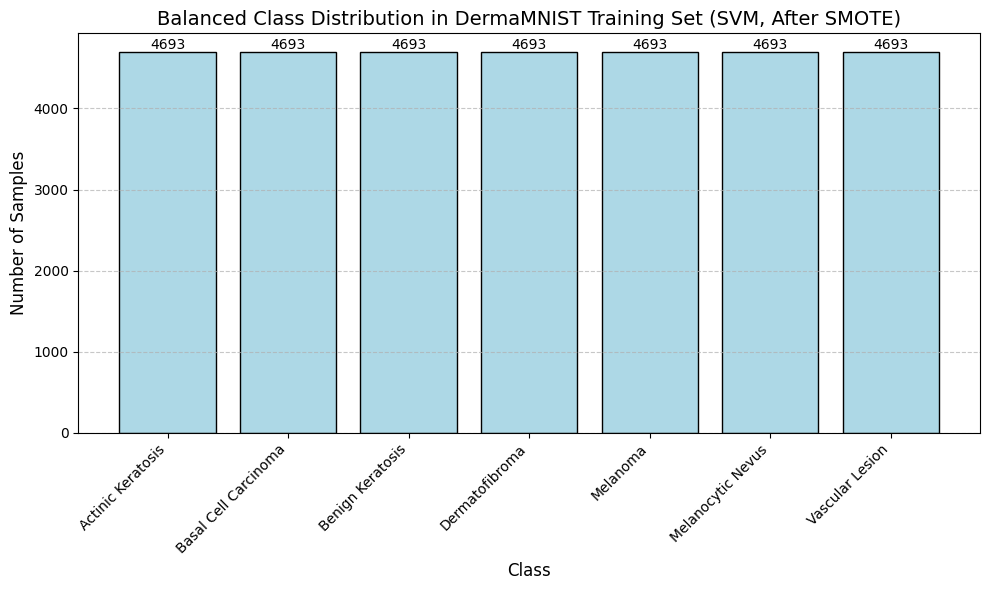

In [43]:
# Plot balanced training class distribution
unique, counts = np.unique(y_train_balanced, return_counts=True)
support_balanced = counts[np.argsort(unique)]
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, support_balanced, color='lightblue', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
             ha='center', va='bottom', fontsize=10)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Balanced Class Distribution in DermaMNIST Training Set (SVM, After SMOTE)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('svm_balanced_class_distribution.png')
# plt.close()

In [44]:
# Train SVM with class weights
model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
model.fit(X_train_balanced, y_train_balanced)

SVC(class_weight='balanced', random_state=42)

In [45]:
# Evaluate on validation set
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=classes))


Validation Accuracy: 0.6730
Validation Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis       0.38      0.52      0.44        33
Basal Cell Carcinoma       0.46      0.58      0.51        52
    Benign Keratosis       0.42      0.53      0.47       110
      Dermatofibroma       0.43      0.25      0.32        12
            Melanoma       0.36      0.67      0.47       111
   Melanocytic Nevus       0.91      0.72      0.81       671
     Vascular Lesion       0.67      0.57      0.62        14

            accuracy                           0.67      1003
           macro avg       0.52      0.55      0.52      1003
        weighted avg       0.75      0.67      0.70      1003



In [46]:
# Evaluate on test set
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=classes))


Test Accuracy: 0.6494
Test Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis       0.30      0.50      0.38        66
Basal Cell Carcinoma       0.37      0.50      0.42       103
    Benign Keratosis       0.44      0.49      0.47       220
      Dermatofibroma       0.21      0.22      0.21        23
            Melanoma       0.31      0.54      0.39       223
   Melanocytic Nevus       0.90      0.72      0.80      1341
     Vascular Lesion       0.70      0.55      0.62        29

            accuracy                           0.65      2005
           macro avg       0.46      0.50      0.47      2005
        weighted avg       0.73      0.65      0.68      2005



# **Gradient Boosting**

In [47]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100)

# Train the model
gb_model.fit(X_train, y_train)

# Validate the model
y_val_pred = gb_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_class_report = classification_report(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, gb_model.predict_proba(X_val), multi_class='ovr')

print(f"Validation Accuracy: {val_accuracy}")
print("Validation Confusion Matrix:")
print(val_conf_matrix)
print("Validation Classification Report:")
print(val_class_report)
print(f"Validation ROC-AUC: {val_roc_auc}")

Validation Accuracy: 0.7248255234297108
Validation Confusion Matrix:
[[  9   5   5   0   1  13   0]
 [  4  22   4   1   2  19   0]
 [  2  10  39   1   3  55   0]
 [  3   5   1   0   0   3   0]
 [  0   1  10   1  23  76   0]
 [  3   2  22   0  11 631   2]
 [  0   0   0   1   1   9   3]]
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.27      0.33        33
           1       0.49      0.42      0.45        52
           2       0.48      0.35      0.41       110
           3       0.00      0.00      0.00        12
           4       0.56      0.21      0.30       111
           5       0.78      0.94      0.85       671
           6       0.60      0.21      0.32        14

    accuracy                           0.72      1003
   macro avg       0.48      0.34      0.38      1003
weighted avg       0.69      0.72      0.69      1003

Validation ROC-AUC: 0.8839087119402981


In [48]:
# Test the model
y_test_pred = gb_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_class_report = classification_report(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, gb_model.predict_proba(X_test), multi_class='ovr')

print(f"Test Accuracy: {test_accuracy}")
print("Test Confusion Matrix:")
print(test_conf_matrix)
print("Test Classification Report:")
print(test_class_report)
print(f"Test ROC-AUC: {test_roc_auc}")


Test Accuracy: 0.7201995012468828
Test Confusion Matrix:
[[  17   13    9    1    3   23    0]
 [   3   43   12    4    2   38    1]
 [   4    9   89    0   13  105    0]
 [   2    6    2    0    1   12    0]
 [   3    4   25    2   36  151    2]
 [   6   18   30    3   23 1256    5]
 [   1    5    2    0    2   16    3]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.26      0.33        66
           1       0.44      0.42      0.43       103
           2       0.53      0.40      0.46       220
           3       0.00      0.00      0.00        23
           4       0.45      0.16      0.24       223
           5       0.78      0.94      0.85      1341
           6       0.27      0.10      0.15        29

    accuracy                           0.72      2005
   macro avg       0.42      0.33      0.35      2005
weighted avg       0.67      0.72      0.68      2005

Test ROC-AUC: 0.8834385806763948


# **Convoluted Neural Network**

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from medmnist import DermaMNIST
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Define a simple CNN model
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [50]:
# Initialize the CNN model
model = CNN(in_channels=3, num_classes=7)  # Assuming 3 channels (RGB) and 7 classes

# Data preprocessing and augmentation
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the data with transformations
train_dataset = DermaMNIST(split="train", transform=data_transform, download=True)
test_dataset = DermaMNIST(split="test", transform=data_transform, download=True)
val_dataset = DermaMNIST(split="val", transform=data_transform, download=True)

In [51]:
# Encapsulate data into dataloader form
BATCH_SIZE = 128
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [52]:
# Training the model
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        targets = targets.squeeze().long()  # Ensure targets are the correct shape and type
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {running_loss/len(train_loader)}")



Epoch [1/10], Loss: 6.326836143840443
Epoch [2/10], Loss: 0.9526867877353321
Epoch [3/10], Loss: 0.8030812426046892
Epoch [4/10], Loss: 0.743985402584076
Epoch [5/10], Loss: 0.7420477173545144
Epoch [6/10], Loss: 0.6865731407295573
Epoch [7/10], Loss: 0.6381480580026453
Epoch [8/10], Loss: 0.6069031005555933
Epoch [9/10], Loss: 0.5687450490214608
Epoch [10/10], Loss: 0.5638668380000375


In [53]:
# Validate the model
model.eval()
val_correct = 0
val_total = 0
with torch.no_grad():
    for inputs, targets in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        val_total += targets.size(0)
        val_correct += (predicted == targets).sum().item()

val_accuracy = val_correct / val_total
print(f"Validation Accuracy: {val_accuracy}")



Validation Accuracy: 66.31405782652044


In [54]:
# Test the model
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += targets.size(0)
        test_correct += (predicted == targets).sum().item()

test_accuracy = test_correct / test_total
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 67.31820448877805


In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Convert predictions and targets to numpy arrays for metric calculations
def get_predictions_and_targets(loader, model):
    all_preds = []
    all_targets = []
    all_probs = []
    model.eval()
    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_targets), np.array(all_probs)

In [56]:
# Get predictions, targets, and probabilities for validation and test sets
val_preds, val_targets, val_probs = get_predictions_and_targets(val_loader, model)
test_preds, test_targets, test_probs = get_predictions_and_targets(test_loader, model)

In [57]:
# Calculate metrics for validation set
val_precision = precision_score(val_targets, val_preds, average='weighted')
val_recall = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
val_roc_auc = roc_auc_score(val_targets, val_probs, multi_class='ovr')


In [58]:
print(f"Validation Precision: {val_precision}")
print(f"Validation Recall: {val_recall}")
print(f"Validation F1 Score: {val_f1}")
print(f"Validation ROC-AUC: {val_roc_auc}")



Validation Precision: 0.7187347743588061
Validation Recall: 0.7337986041874377
Validation F1 Score: 0.7125095173930514
Validation ROC-AUC: 0.9022614504372568


In [59]:
# Calculate metrics for test set
test_precision = precision_score(test_targets, test_preds, average='weighted')
test_recall = recall_score(test_targets, test_preds, average='weighted')
test_f1 = f1_score(test_targets, test_preds, average='weighted')
test_roc_auc = roc_auc_score(test_targets, test_probs, multi_class='ovr')


In [60]:

print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1 Score: {test_f1}")
print(f"Test ROC-AUC: {test_roc_auc}")

Test Precision: 0.710750894670418
Test Recall: 0.7346633416458853
Test F1 Score: 0.7105669322137661
Test ROC-AUC: 0.9002893040608344


#Five fold cross validation


In [61]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from medmnist import DermaMNIST, INFO
import warnings
warnings.filterwarnings('ignore')

In [62]:
# Define CNN model (from the provided code)
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc = nn.Sequential(
            nn.Linear(128 * 3 * 3, 512),  # Adjusted for 28x28 input
            nn.ReLU(),
            nn.Linear(512, num_classes))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [63]:
# Data preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Load DermaMNIST datasets
train_dataset = DermaMNIST(split='train', transform=data_transform, download=True)
val_dataset = DermaMNIST(split='val', transform=data_transform, download=True)
test_dataset = DermaMNIST(split='test', transform=data_transform, download=True)

In [64]:
# Prepare data for scikit-learn models (flatten images)
def prepare_sklearn_data(dataset):
    images, labels = dataset.imgs, dataset.labels
    images = images.reshape(len(images), -1) / 255.0  # Flatten and normalize
    labels = labels.ravel()
    return images, labels

X_train, y_train = prepare_sklearn_data(train_dataset)
X_val, y_val = prepare_sklearn_data(val_dataset)
X_test, y_test = prepare_sklearn_data(test_dataset)

# Combine train and val for cross-validation
X_train_val = np.concatenate([X_train, X_val], axis=0)
y_train_val = np.concatenate([y_train, y_val], axis=0)

In [65]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'CNN': CNN(in_channels=1, num_classes=7)  # 1 channel for DermaMNIST
}

In [66]:
# 5-fold cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = {name: [] for name in models.keys()}
test_accuracies = {}

In [67]:
# Evaluate scikit-learn models
for name, model in models.items():
    if name != 'CNN':
        print(f"\nCross-validation for {name}...")
        for train_idx, val_idx in skf.split(X_train_val, y_train_val):
            X_tr, X_val = X_train_val[train_idx], X_train_val[val_idx]
            y_tr, y_val = y_train_val[train_idx], y_train_val[val_idx]
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            cv_scores[name].append(accuracy_score(y_val, y_pred))
        # Test set evaluation
        model.fit(X_train_val, y_train_val)  # Train on full train+val
        y_test_pred = model.predict(X_test)
        test_accuracies[name] = accuracy_score(y_test, y_test_pred)
        print(f"{name} CV Accuracy: {np.mean(cv_scores[name]):.4f} ± {np.std(cv_scores[name]):.4f}")
        print(f"{name} Test Accuracy: {test_accuracies[name]:.4f}")


Cross-validation for Logistic Regression...
Logistic Regression CV Accuracy: 0.6910 ± 0.0051
Logistic Regression Test Accuracy: 0.6993

Cross-validation for SVM...
SVM CV Accuracy: 0.5574 ± 0.0164
SVM Test Accuracy: 0.5651

Cross-validation for Gradient Boosting...
Gradient Boosting CV Accuracy: 0.7146 ± 0.0035
Gradient Boosting Test Accuracy: 0.7247


In [71]:
# CNN cross-validation and test evaluation
print("\nCross-validation for CNN...")
BATCH_SIZE = 128
NUM_EPOCHS = 10
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for train_idx, val_idx in skf.split(X_train_val, y_train_val):
    # Prepare data for this fold
    train_subset = data.Subset(train_dataset, train_idx)
    val_subset = data.Subset(val_dataset, [i - len(train_dataset) if i >= len(train_dataset) else i for i in val_idx])
    train_loader = data.DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = data.DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

    # Initialize CNN for this fold
    model = CNN(in_channels=1, num_classes=7).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train
    model.train()
    for epoch in range(NUM_EPOCHS):
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

    # Validate
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    cv_scores['CNN'].append(accuracy_score(y_true, y_pred))


Cross-validation for CNN...


IndexError: index 7989 is out of bounds for axis 0 with size 7007

In [ ]:
# Train CNN on full train+val and evaluate on test set
train_val_dataset = data.ConcatDataset([train_dataset, val_dataset])
train_val_loader = data.DataLoader(train_val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = CNN(in_channels=1, num_classes=7).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Train
model.train()
for epoch in range(NUM_EPOCHS):
    for inputs, targets in train_val_loader:
        inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

In [ ]:
# Test
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(targets.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
test_accuracies['CNN'] = accuracy_score(y_true, y_pred)

print(f"CNN CV Accuracy: {np.mean(cv_scores['CNN']):.4f} ± {np.std(cv_scores['CNN']):.4f}")
print(f"CNN Test Accuracy: {test_accuracies['CNN']:.4f}")

# Summary
print("\nModel Comparison:")
print(f"{'Model':<20} {'CV Accuracy':<15} {'Test Accuracy':<15}")
for name in models.keys():
    print(f"{name:<20} {np.mean(cv_scores[name]):.4f} ± {np.std(cv_scores[name]):.4f} {test_accuracies[name]:.4f}")